# Mission 3: Understand the Content

# 🧠 Mission 3: Understand the Data

```{admonition} 🎯 Mission Brief
:class: note

Congratulations, Urban Data Investigator.

You have successfully:

- located a dataset
- retrieved it via API
- inspected the replication package

Now it is time to understand what the data actually contains.

In this mission, you will:

- 📊 explore variables and indicators
- 🧾 understand what each attribute represents
- 🔍 identify variables useful for analysis
- 🧠 interpret the meaning of the data

🏅 **Badge to unlock:** Data Interpreter
```

```{admonition} 🔎 Clue 1
Read the case notes Before opening the data, start with the documentation. 
The `README.md` file acts like the case notes for the replication package. It can explain the purpose of the study, the available files, and how the original workflow was organised.
```


# 🔎 What is inside the dataset?

Before analysing anything, let's first see what information is available.

Each **row** represents an observation, while each **column** stores an attribute or indicator.

# Define the data folder

In [6]:
import geopandas as gpd
from pathlib import Path

data_dir = Path("data/g_raw")

In [7]:
berlin_file = data_dir / "berlin_3D_canopy_stats_lczv3_grid100m_urau2021_epsg25833.gpkg"

gdf = gpd.read_file(berlin_file)

/opt/conda/envs/worker_env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


That message is a warning, not an error. Your GeoPackage should still have loaded successfully.

The file contains a geometry type called Measured 3D MultiPolygon. GeoPandas/pyogrio does not support the extra M (measure) dimension, so it converts the geometry to MultiPolygon Z instead. The Z dimension is kept; only the M values are dropped.

You can confirm the data loaded with:

In [8]:
gdf.head()

,tile_id,centroid_x,centroid_y,cell_area,lcz_class_value,chm_area,chm_volume,bldg_area,bldg_volume,geometry
0,3969_58220,396950.0,5822050.0,10000.0,0,1952.75,15642.54,522.25,7440.57,"MULTIPOLYGON (((397000 5822000, 396900 5822000..."
1,3969_58221,396950.0,5822150.0,10000.0,0,974.50,7245.98,5470.00,76521.83,"MULTIPOLYGON (((397000 5822100, 396900 5822100..."
2,3969_58222,396950.0,5822250.0,10000.0,0,204.00,1510.19,6977.50,97985.20,"MULTIPOLYGON (((397000 5822200, 396900 5822200..."
3,3969_58223,396950.0,5822350.0,10000.0,0,871.25,9699.76,2929.25,28673.67,"MULTIPOLYGON (((397000 5822300, 396900 5822300..."
4,3970_58220,397050.0,5822050.0,10000.0,0,1610.00,15820.57,2557.25,40974.82,"MULTIPOLYGON (((397100 5822000, 397093 5822000..."


and check the geometry types with:

In [9]:
gdf.geometry.geom_type.value_counts()

MultiPolygon    90530
Name: count, dtype: int64

# 🧾 Explore the variables

Let's list the available columns and see what type of information they contain.

In [10]:
for column in gdf.columns:
    print(f"• {column}")

• tile_id
• centroid_x
• centroid_y
• cell_area
• lcz_class_value
• chm_area
• chm_volume
• bldg_area
• bldg_volume
• geometry


In [11]:
gdf.dtypes

tile_id              object
centroid_x          float64
centroid_y          float64
cell_area           float64
lcz_class_value       int32
chm_area            float64
chm_volume          float64
bldg_area           float64
bldg_volume         float64
geometry           geometry
dtype: object

Some columns contain text or spatial information, while others contain numbers that we can analyse.

Let's find the numeric variables.

In [12]:
numeric_columns = gdf.select_dtypes(include="number").columns.tolist()

numeric_columns

['centroid_x',
 'centroid_y',
 'cell_area',
 'lcz_class_value',
 'chm_area',
 'chm_volume',
 'bldg_area',
 'bldg_volume']

# 🔬 Inspect the numbers

A quick statistical summary helps us understand the range and variation of each numeric variable.

In [13]:
gdf[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
centroid_x,90530.0,3.915412e+05,10666.997705,369999.92,382950.00,391450.000,399750.000,415717.97
centroid_y,90530.0,5.818014e+06,7870.481451,5799565.05,5811450.00,5817450.000,5824150.000,5837215.87
cell_area,90530.0,9.845884e+03,1056.149281,0.01,10000.00,10000.000,10000.000,10000.00
lcz_class_value,90530.0,8.140771e+00,3.513777,0.00,6.00,6.000,11.000,17.00
chm_area,90530.0,3.961143e+03,2910.194627,0.00,1852.25,3266.250,5639.000,9993.75
chm_volume,90530.0,5.762480e+04,62298.854941,0.00,14374.67,32292.820,75916.965,297611.28
bldg_area,90530.0,1.077154e+03,1314.386779,0.00,0.00,674.250,1720.750,10000.00
bldg_volume,90530.0,1.414775e+04,23053.732760,0.00,0.00,4617.855,17799.090,319464.86


```{admonition} Tip
Look especially at the **minimum**, **median (`50%`)**, **mean**, and **maximum**.

Do any variables stand out?
```

# 📊 Look at one indicator

Tables are useful, but a simple plot can make patterns easier to recognise.

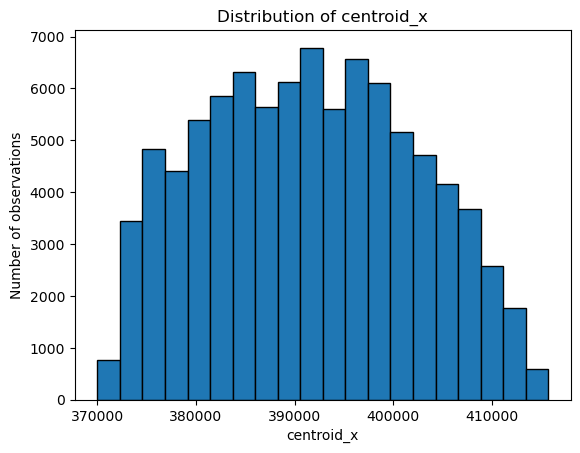

In [14]:
import matplotlib.pyplot as plt

indicator = numeric_columns[0]

gdf[indicator].plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title(f"Distribution of {indicator}")
plt.xlabel(indicator)
plt.ylabel("Number of observations")
plt.show()

What do you notice?

- Are most values similar?
- Are there very high or low values?
- What might those differences mean?

```{admonition} 🕵️ Investigator challenge
:class: note

Choose another numeric indicator and replace the variable below:

`indicator = "YOUR_COLUMN_NAME"`

Then explore its distribution.

Can you explain what a **high** and a **low** value mean?

# 🧠 From numbers to meaning

A variable name alone is not enough.

Before using an indicator, check its **definition, unit, and interpretation** in the dataset metadata.

> What does the indicator measure?  
> What does a high value mean?  
> Why might it be useful for your investigation?

```{raw} html
<div class="admonition tip">
  <p class="admonition-title">🎉 Mission Complete — Badge Unlocked!</p>

  <h3>🏆 Data Interpreter</h3>

  <p>You successfully decoded the dataset and uncovered what its variables can tell us.</p>

  <ul>
    <li>✔ Variables and indicators explored</li>
    <li>✔ Data types identified</li>
    <li>✔ Numeric indicators examined</li>
    <li>✔ Data patterns interpreted</li>
  </ul>

  <p><strong>Status:</strong> Mission 3 complete</p>

  <button onclick="completeMission3()" style="padding: 10px 16px; font-weight: bold; border-radius: 6px; cursor: pointer;">
    ✅ Complete Mission 3
  </button>

  <p id="mission-3-complete-message" style="font-weight: bold; margin-top: 12px;"></p>
</div>

<script>
function completeMission3() {
  // This token unlocks Mission 4
  localStorage.setItem("urban_data_mission_3_completed", "true");

  // Store badge name
  localStorage.setItem("urban_data_badge_3", "Data Interpreter");

  // Store completion time
  localStorage.setItem("urban_data_mission_3_completed_at", new Date().toISOString());

  document.getElementById("mission-3-complete-message").innerHTML =
    "🔓 Mission 4 unlocked! Badge added to your gallery.";
}
</script>

```{admonition} Mission accomplished 🎉
:class: tip

You can now identify, explore, and interpret variables in the dataset.

🏅 **Badge unlocked: Data Interpreter**

Next, we will investigate **where these patterns occur**. 🗺️

```{admonition} 🎮 Mission Progress
:class: note, dropdown

**Your Journey**

🟢 **Mission 1: Locate & Retrieve Data ✅ 
🟢 Mission 2: Inspect the Package ✅  
🟢 **Mission 3: Understand the Data ← Current**    
⚪ Mission 4: Generate Insights 🔒  
⚪ Mission 5: Create Visual Evidence 🔒  
⚪ Mission 6: Map the City 🔒  
⚪ Mission 7: Extend the Analysis 🔒  
⚪ Final Mission: Tell the Data Story 🔒  

**Progress:** ▰▰▰▱▱▱▱▱ 3/8 Complete

```{admonition}  🚧 Next Mission Preview
:class: note, dropdown

# 🔍 Mission 4: Generate Insights

Your next challenge is to move from **understanding the data** to **discovering patterns within it**.

You will learn how to:

- 📊 summarise key indicators
- 🔎 compare values and patterns
- 📈 identify interesting differences
- 🧠 turn observations into first insights

**The investigation continues — what can the data reveal?**
```